## 1. Instalación de Dependencias

Ejecuta esta celda primero para instalar las librerías necesarias:

In [1]:
# Instalar dependencias necesarias
!pip install nlpaug transformers torch tqdm nltk

## 2. Importar Librerías

In [2]:
import pandas as pd
import numpy as np
import nlpaug.augmenter.word as naw
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Descargar recursos de NLTK necesarios para synonym augmentation
import nltk
print("Descargando recursos de NLTK...")
try:
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)  # Open Multilingual Wordnet
    nltk.download('averaged_perceptron_tagger', quiet=True)
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)  # Versión específica para inglés
    print("✓ Recursos de NLTK descargados correctamente")
except Exception as e:
    print(f"⚠️  Error descargando NLTK: {e}")
    print("Intentando continuar de todas formas...")

print("✓ Librerías importadas correctamente")

/home/noe/Documentos/IA-F5-Proyecto/proyecto10-grupo5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargando recursos de NLTK...
✓ Recursos de NLTK descargados correctamente
✓ Librerías importadas correctamente
✓ Recursos de NLTK descargados correctamente
✓ Librerías importadas correctamente


## 3. Cargar Dataset Original

In [3]:
# Cargar el dataset original (SIN augmentation previo)
# IMPORTANTE: Usa el dataset base, no el ya aumentado
df_original = pd.read_csv('../resources/dataset/youtoxic_english_1000.csv', index_col=0)
labels = ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']

print(f"Dataset original cargado: {len(df_original)} filas")
print(f"\nDistribución de etiquetas actual:")
for label in labels:
    count = df_original[label].sum()
    pct = (count / len(df_original)) * 100
    print(f"  {label}: {count} ({pct:.2f}%)")

Dataset original cargado: 1000 filas

Distribución de etiquetas actual:
  IsToxic: 462 (46.20%)
  IsAbusive: 353 (35.30%)
  IsProvocative: 161 (16.10%)
  IsObscene: 100 (10.00%)
  IsHatespeech: 138 (13.80%)
  IsRacist: 125 (12.50%)


## 4. Configurar Augmenters

Vamos a usar Synonym Replacement que es más rápido y no requiere GPU. Si tienes GPU disponible, puedes descomentar las otras técnicas.

In [4]:
print("Configurando augmenters...")

# Synonym Replacement (rápido, no requiere internet ni GPU)
synonym_aug = naw.SynonymAug(aug_src='wordnet', aug_max=3)

# OPCIONAL: Descomentar si tienes GPU y quieres usar back-translation
# back_trans_aug = naw.BackTranslationAug(
#     from_model_name='facebook/wmt19-en-de',
#     to_model_name='facebook/wmt19-de-en',
#     device='cuda'
# )

# OPCIONAL: Descomentar si tienes GPU y quieres usar BERT
# contextual_aug = naw.ContextualWordEmbsAug(
#     model_path='bert-base-uncased',
#     action="substitute",
#     device='cuda'
# )

print("✓ Augmenters configurados")

Configurando augmenters...
✓ Augmenters configurados
✓ Augmenters configurados


## 5. Función de Augmentation

In [5]:
def augment_text_for_label(text, label_name, num_variations=3):
    """
    Genera variaciones de un texto usando synonym replacement.
    
    Args:
        text: Texto original
        label_name: Nombre de la etiqueta (para logging)
        num_variations: Número de variaciones a generar
    
    Returns:
        Lista con el texto original + variaciones
    """
    variations = []
    
    try:
        # Generar variaciones con synonym replacement
        for _ in range(num_variations):
            augmented = synonym_aug.augment(text)
            if augmented and augmented != text:
                variations.append(augmented)
        
        # Si tienes back-translation habilitado:
        # augmented = back_trans_aug.augment(text)
        # if augmented and augmented != text:
        #     variations.append(augmented)
        
    except Exception as e:
        print(f"Error augmentando texto: {e}")
    
    return variations

print("✓ Función de augmentation definida")

✓ Función de augmentation definida


## 6. Definir Objetivos de Augmentation

In [6]:
# Definir cuántos ejemplos queremos por clase
# IMPORTANTE: IsToxic y IsAbusive YA tienen suficientes datos - NO aumentar
# Solo aumentamos las 4 clases minoritarias
target_samples = {
    'IsToxic': 462,         # Mantener EXACTAMENTE lo que hay - NO aumentar
    'IsAbusive': 353,       # Mantener EXACTAMENTE lo que hay - NO aumentar  
    'IsProvocative': 250,   # Aumentar de 161 a 250
    'IsObscene': 250,       # Aumentar de 100 a 250
    'IsHatespeech': 250,    # Aumentar de 138 a 250
    'IsRacist': 250         # Aumentar de 125 a 250
}

print("Objetivos de augmentation definidos:")
print(f"{'Etiqueta':<20} {'Actual':>10} {'Objetivo':>10} {'Generar':>12}")
print("-" * 55)
for label, target in target_samples.items():
    current = df_original[label].sum()
    needed = max(0, target - current)
    status = "✓ NO aumentar" if needed == 0 else f"+ {needed}"
    print(f"{label:<20} {current:>10} {target:>10} {status:>12}")

Objetivos de augmentation definidos:
Etiqueta                 Actual   Objetivo      Generar
-------------------------------------------------------
IsToxic                     462        462 ✓ NO aumentar
IsAbusive                   353        353 ✓ NO aumentar
IsProvocative               161        250         + 89
IsObscene                   100        250        + 150
IsHatespeech                138        250        + 112
IsRacist                    125        250        + 125


## 7. Aplicar Data Augmentation

⚠️ **NOTA:** Este proceso puede tardar 5-15 minutos dependiendo de la cantidad de datos a generar.

In [7]:
augmented_rows = []

print("="*100)
print("INICIANDO DATA AUGMENTATION")
print("="*100)

for label in labels:
    print(f"\n{'='*100}")
    print(f"Procesando etiqueta: {label}")
    print(f"{'='*100}")
    
    # Filtrar textos positivos para esta etiqueta
    positive_samples = df_original[df_original[label] == 1].copy()
    current_count = len(positive_samples)
    target = target_samples[label]
    
    print(f"Ejemplos actuales: {current_count}")
    print(f"Objetivo: {target}")
    
    if current_count >= target:
        print(f"✓ Ya tiene suficientes ejemplos")
        continue
    
    # PRIORIZAR textos que NO tienen IsToxic ni IsAbusive para minimizar su crecimiento
    # Ordenar: primero los que NO tienen las etiquetas mayoritarias
    positive_samples['_priority'] = (
        (~positive_samples['IsToxic'].astype(bool)).astype(int) + 
        (~positive_samples['IsAbusive'].astype(bool)).astype(int)
    )
    positive_samples = positive_samples.sort_values('_priority', ascending=False)
    
    # Calcular cuántas variaciones necesitamos por texto
    needed = target - current_count
    variations_per_text = max(1, int(np.ceil(needed / current_count)))
    
    print(f"Necesitamos generar: {needed} ejemplos")
    print(f"Generando ~{variations_per_text} variaciones por texto...")
    print(f"Priorizando textos sin IsToxic/IsAbusive para minimizar su aumento")
    
    generated_count = 0
    for idx, row in tqdm(positive_samples.iterrows(), total=len(positive_samples), desc=f"Augmentando {label}"):
        text = row['Text']
        
        # Generar variaciones
        variations = augment_text_for_label(text, label, num_variations=variations_per_text)
        
        # Añadir cada variación
        for var_text in variations:
            if generated_count >= needed:
                break
                
            new_row = row.copy()
            new_row['Text'] = var_text
            # Eliminar columna auxiliar
            if '_priority' in new_row:
                new_row = new_row.drop('_priority')
            augmented_rows.append(new_row)
            generated_count += 1
        
        if generated_count >= needed:
            break
    
    print(f"✓ Generados {generated_count} ejemplos nuevos para {label}")

print(f"\n{'='*100}")
print(f"✅ DATA AUGMENTATION COMPLETADO")
print(f"Total de ejemplos generados: {len(augmented_rows)}")
print(f"{'='*100}")

INICIANDO DATA AUGMENTATION

Procesando etiqueta: IsToxic
Ejemplos actuales: 462
Objetivo: 462
✓ Ya tiene suficientes ejemplos

Procesando etiqueta: IsAbusive
Ejemplos actuales: 353
Objetivo: 353
✓ Ya tiene suficientes ejemplos

Procesando etiqueta: IsProvocative
Ejemplos actuales: 161
Objetivo: 250
Necesitamos generar: 89 ejemplos
Generando ~1 variaciones por texto...
Priorizando textos sin IsToxic/IsAbusive para minimizar su aumento


Augmentando IsProvocative:  55%|█████▍    | 88/161 [00:00<00:00, 268.41it/s]


✓ Generados 89 ejemplos nuevos para IsProvocative

Procesando etiqueta: IsObscene
Ejemplos actuales: 100
Objetivo: 250
Necesitamos generar: 150 ejemplos
Generando ~2 variaciones por texto...
Priorizando textos sin IsToxic/IsAbusive para minimizar su aumento


Augmentando IsObscene:  74%|███████▍  | 74/100 [00:00<00:00, 207.31it/s]


✓ Generados 150 ejemplos nuevos para IsObscene

Procesando etiqueta: IsHatespeech
Ejemplos actuales: 138
Objetivo: 250
Necesitamos generar: 112 ejemplos
Generando ~1 variaciones por texto...
Priorizando textos sin IsToxic/IsAbusive para minimizar su aumento


Augmentando IsHatespeech:  80%|████████  | 111/138 [00:00<00:00, 417.15it/s]


✓ Generados 112 ejemplos nuevos para IsHatespeech

Procesando etiqueta: IsRacist
Ejemplos actuales: 125
Objetivo: 250
Necesitamos generar: 125 ejemplos
Generando ~1 variaciones por texto...
Priorizando textos sin IsToxic/IsAbusive para minimizar su aumento


Augmentando IsRacist:  99%|█████████▉| 124/125 [00:00<00:00, 388.41it/s]

✓ Generados 125 ejemplos nuevos para IsRacist

✅ DATA AUGMENTATION COMPLETADO
Total de ejemplos generados: 476


## 8. Combinar Datasets

In [8]:
# Crear dataframe con datos aumentados
df_augmented = pd.DataFrame(augmented_rows)

# Combinar con el dataset original
df_final = pd.concat([df_original, df_augmented], ignore_index=True)

print(f"\n{'='*100}")
print(f"RESUMEN FINAL")
print(f"{'='*100}")
print(f"Dataset original: {len(df_original)} filas")
print(f"Datos aumentados: {len(df_augmented)} filas")
print(f"Dataset final: {len(df_final)} filas")
print(f"Incremento: {(len(df_final) / len(df_original) - 1) * 100:.2f}%")

print(f"\nDistribución final de etiquetas:")
print(f"{'Etiqueta':<20} {'Original':>12} {'Final':>12} {'% Aumento':>15}")
print("-" * 60)
for label in labels:
    count_orig = df_original[label].sum()
    count_final = df_final[label].sum()
    pct_orig = (count_orig / len(df_original)) * 100
    pct_final = (count_final / len(df_final)) * 100
    increase = ((count_final / count_orig) - 1) * 100 if count_orig > 0 else 0
    print(f"{label:<20} {count_orig:>12} {count_final:>12} {increase:>14.1f}%")


RESUMEN FINAL
Dataset original: 1000 filas
Datos aumentados: 476 filas
Dataset final: 1476 filas
Incremento: 47.60%

Distribución final de etiquetas:
Etiqueta                 Original        Final       % Aumento
------------------------------------------------------------
IsToxic                       462          938          103.0%
IsAbusive                     353          620           75.6%
IsProvocative                 161          300           86.3%
IsObscene                     100          275          175.0%
IsHatespeech                  138          405          193.5%
IsRacist                      125          377          201.6%


## 9. Guardar Dataset Balanceado

In [9]:
# Guardar el nuevo dataset
output_path = '../resources/dataset/augmented_youtoxic_balanced.csv'
df_final.to_csv(output_path)

print(f"\n{'='*100}")
print(f"✅ DATASET GUARDADO EXITOSAMENTE")
print(f"{'='*100}")
print(f"Ubicación: {output_path}")
print(f"\nPróximos pasos:")
print(f"1. Volver al notebook 'eda-svm-multi-label.ipynb'")
print(f"2. En la celda 4, cambiar la ruta del dataset a:")
print(f"   df = pd.read_csv('../resources/dataset/augmented_youtoxic_balanced.csv', index_col=0)")
print(f"3. Re-ejecutar todo el notebook desde la celda 4")
print(f"4. Comparar los nuevos resultados con los anteriores")
print(f"\n🎯 Expectativa: F1-Score > 0.5 en todas las etiquetas, overfitting < 10%")
print(f"{'='*100}")


✅ DATASET GUARDADO EXITOSAMENTE
Ubicación: ../resources/dataset/augmented_youtoxic_balanced.csv

Próximos pasos:
1. Volver al notebook 'eda-svm-multi-label.ipynb'
2. En la celda 4, cambiar la ruta del dataset a:
   df = pd.read_csv('../resources/dataset/augmented_youtoxic_balanced.csv', index_col=0)
3. Re-ejecutar todo el notebook desde la celda 4
4. Comparar los nuevos resultados con los anteriores

🎯 Expectativa: F1-Score > 0.5 en todas las etiquetas, overfitting < 10%


## 10. Visualización de Mejoras

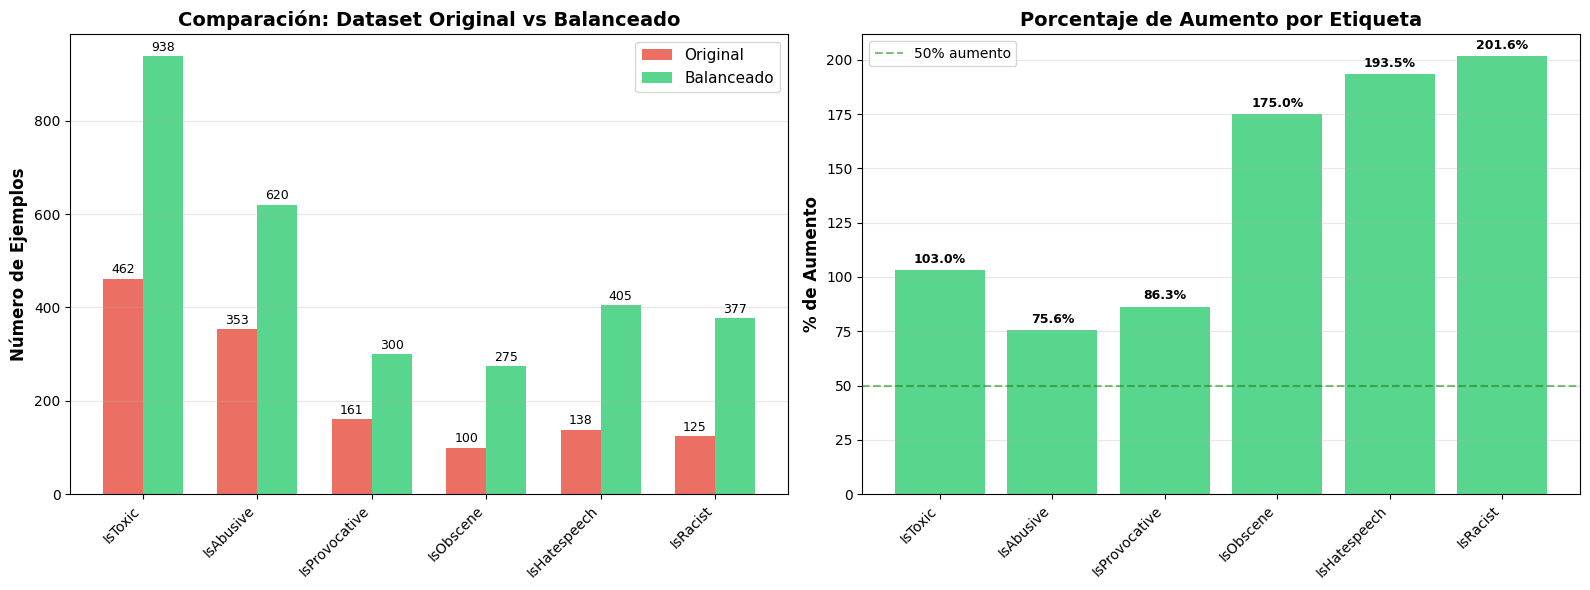

✓ Gráfico guardado como 'augmentation_comparison.png'


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comparación visual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Conteo antes y después
x = np.arange(len(labels))
width = 0.35

counts_orig = [df_original[label].sum() for label in labels]
counts_final = [df_final[label].sum() for label in labels]

bars1 = axes[0].bar(x - width/2, counts_orig, width, label='Original', alpha=0.8, color='#e74c3c')
bars2 = axes[0].bar(x + width/2, counts_final, width, label='Balanceado', alpha=0.8, color='#2ecc71')

axes[0].set_ylabel('Número de Ejemplos', fontsize=12, fontweight='bold')
axes[0].set_title('Comparación: Dataset Original vs Balanceado', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Añadir valores
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 5,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Porcentaje de aumento
increases = [((df_final[label].sum() / df_original[label].sum()) - 1) * 100 
             if df_original[label].sum() > 0 else 0 for label in labels]

colors = ['#2ecc71' if inc > 50 else '#f39c12' if inc > 20 else '#3498db' for inc in increases]
bars = axes[1].bar(labels, increases, alpha=0.8, color=colors)

axes[1].set_ylabel('% de Aumento', fontsize=12, fontweight='bold')
axes[1].set_title('Porcentaje de Aumento por Etiqueta', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=50, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='50% aumento')
axes[1].legend()

# Añadir valores
for i, (bar, val) in enumerate(zip(bars, increases)):
    axes[1].text(bar.get_x() + bar.get_width()/2., val + 2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado como 'augmentation_comparison.png'")